# Stratified performance analysis — cross-region (snapshot 14y)

Where does TESSERA actually help? Breaks per-station MAE down along
multiple stratification axes to surface regimes in which the TESSERA-vs-baseline
gap is large or small. Source data is `test_station_errors.npz` per run —
no retraining or re-evaluation needed.

**Architectures compared per (folder, variable) pair:**

* TESSERA: top-1 vanilla **VAE-latents** variant by per-distribution MAE
  (selected via `_helpers._top_n_experiments` with category `TESSERA_VANILLA`,
  `encoder="vae"`).
* Baseline: top-1 trained no-TESSERA bilinear variant
  (`_top_n_experiments` with category `TRAINED_NO_TESSERA`).

**Variable / distribution preferences:**

* `t2m`  → gaussian (only head trained for it).
* `wind` → prefer `truncated_normal`, fall back to `gaussian`. The point estimate
  used in `{var}_station_mae` is each head's predictive mean
  (matches Gaussian's μ exactly; uses the truncated mean for TN), so MAE
  numbers from heterogeneous head families are commensurable.

**Stratification axes:**

1. **Region** (bar chart) — TESSERA-vs-baseline gap per folder.
2. **Elevation** quantile bins — does TESSERA help more for high-elevation
   stations?
3. **|Δ-elevation|** (station vs grid-cell elevation) quantile bins — does
   TESSERA help most where stations are most unrepresentative of their grid
   cell?
4. **Station density** (mean distance to k=5 nearest train stations) — does
   TESSERA help more in data-sparse areas?
5. **Latitude band** (5° bins) — climate-regime proxy.
6. **Season** (DJF / MAM / JJA / SON) — from `test_summary.json`'s aggregate
   `{var}_seasonal_mae`, NOT per-station. Coarser axis, plotted separately.

**Caveats:**

* Baselines do **not** apply the TESSERA+VAE filter at eval time, so the
  baseline test set can be a SUPERSET of the TESSERA one. Per-station
  intersection is computed where direct gap comparison is required.
* Density is computed as Euclidean distance on (lat, lon) within a region —
  for ranking / quantile binning this is fine; absolute distances slightly
  underestimate high-latitude separations (longitude meridians converge).


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

sys.path.insert(0, str(Path.cwd()))
import _helpers
import importlib
importlib.reload(_helpers)
from _helpers import (
    RunCategory,
    _top_n_experiments,
    _augment_df_with_classification,
    output_dir_for_folder,
)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.constrained_layout.use': True,
})


In [2]:
# Per-region snapshot-14y folders (one folder = one region).
FOLDERS = [
    'snapshot_14y_eu',
    'snapshot_14y_us',
    'snapshot_14y_east_asia',
    'snapshot_14y_australia',
    'snapshot_14y_southern_africa',
]
SEEDS = [42, 123, 456]
VARIABLES = ['t2m', 'wind']

# Distribution preference per variable. First entry that has TESSERA-vanilla
# runs in a folder is the one selected for that folder. Wind prefers
# truncated_normal where available, since it's the better-fitting head for
# strictly-positive wind magnitudes; otherwise gaussian.
DIST_PREF = {
    't2m':  ['gaussian'],
    'wind': ['truncated_normal', 'gaussian'],
}

# Where stations.csv lives. Stratification by station density needs the
# full train+test station table — that's the dataset's stations.csv, not
# the per-run NPZ. Adjust if your layout differs.
from tessera_downscaling.paths import dataset_dir
DATASET_DIR = dataset_dir('dataset_timestamp_global')

# Number of nearest train stations for the density proxy.
K_NEAREST = 5

# Number of quantile bins for elevation / |Δ-elev| / density axes.
N_BINS = 4


In [3]:
df_all = _helpers.load_all_results(FOLDERS, seeds=SEEDS)
df_all = _augment_df_with_classification(df_all)
print(f'Loaded {len(df_all)} run records across {len(FOLDERS)} folders.')
if df_all.empty:
    raise RuntimeError(
        'No runs found. Check FOLDERS and that test_summary.json exists '
        'under $TESSERA_DATA_ROOT/training_runs_<folder>/.'
    )
print('\nRun counts per folder:')
print(df_all.groupby('source_folder').size().to_string())


Loaded 1767 run records across 5 folders.

Run counts per folder:
source_folder
snapshot_14y_australia          339
snapshot_14y_east_asia          528
snapshot_14y_eu                 165
snapshot_14y_southern_africa    369
snapshot_14y_us                 366


In [4]:
# For each (folder, variable), pick top-1 TESSERA-vanilla VAE winner +
# top-1 trained-no-TESSERA baseline. Distribution fallback chain follows
# DIST_PREF[variable]; if TESSERA picks one distribution and the baseline
# only has another, both selections are surfaced separately and the
# mismatch is logged.
def pick_winner_pair(df_sub: pd.DataFrame, variable: str) -> dict | None:
    chosen_dist = None
    tessera_name = None
    for dist in DIST_PREF[variable]:
        top = _top_n_experiments(
            df_sub, variable, dist,
            RunCategory.TESSERA_VANILLA, 'single', top_n=1, encoder='vae',
        )
        if top:
            chosen_dist = dist
            tessera_name = top[0]
            break
    if not tessera_name:
        return None

    # Baseline at the same distribution if possible, else fall back to any
    # distribution in DIST_PREF[variable]. Records the chosen distribution.
    baseline_name = None
    baseline_dist = None
    search_dists = [chosen_dist] + [d for d in DIST_PREF[variable] if d != chosen_dist]
    for dist in search_dists:
        top = _top_n_experiments(
            df_sub, variable, dist,
            RunCategory.TRAINED_NO_TESSERA, 'single', top_n=1,
        )
        if top:
            baseline_dist = dist
            baseline_name = top[0]
            break
    if not baseline_name:
        return None

    return {
        'variable':            variable,
        'tessera_distribution': chosen_dist,
        'tessera_experiment':   tessera_name,
        'baseline_distribution': baseline_dist,
        'baseline_experiment':  baseline_name,
    }


winners = []
for folder in FOLDERS:
    sub = df_all[df_all['source_folder'] == folder]
    if sub.empty:
        print(f'[{folder}] no runs; skipping.')
        continue
    for variable in VARIABLES:
        pair = pick_winner_pair(sub, variable)
        if pair is None:
            print(f'[{folder}/{variable}] no usable TESSERA-vanilla + baseline pair.')
            continue
        if pair['tessera_distribution'] != pair['baseline_distribution']:
            print(
                f'[{folder}/{variable}] distribution mismatch: '
                f'TESSERA={pair["tessera_distribution"]} vs '
                f'baseline={pair["baseline_distribution"]}. '
                f'MAE comparison still valid (both report head.mean()), '
                f'but error bars come from different head families.'
            )
        pair['folder'] = folder
        winners.append(pair)

winners_df = pd.DataFrame(winners)[
    ['folder', 'variable',
     'tessera_distribution', 'tessera_experiment',
     'baseline_distribution', 'baseline_experiment']
]
print()
print('=== Chosen winners ===')
with pd.option_context('display.max_colwidth', None, 'display.width', 200):
    print(winners_df.to_string(index=False))



=== Chosen winners ===
                      folder variable tessera_distribution                                                       tessera_experiment baseline_distribution                             baseline_experiment
             snapshot_14y_eu      t2m             gaussian                    t2m_snap_vae_lat16_concat_with_elev_no_static_wd_crps              gaussian                    t2m_snap_setconv_baseline_wd
             snapshot_14y_eu     wind     truncated_normal wind_truncnormal_snap_vae_lat16_proj8_concat_with_elev_no_static_wd_crps      truncated_normal wind_truncnormal_snap_bilinear_baseline_wd_crps
             snapshot_14y_us      t2m             gaussian          t2m_snap_vae_lat16_proj8_mlp_concat_with_elev_no_static_wd_crps              gaussian              t2m_snap_bilinear_baseline_wd_crps
             snapshot_14y_us     wind     truncated_normal                   wind_snap_vae_lat64_proj16_concat_no_elev_no_static_wd      truncated_normal      wind_trun

In [5]:
# For each (folder, role, seed) load test_station_errors.npz; stack into one
# DataFrame. Stations with count==0 (not evaluated) are dropped.
def load_station_records(folder: str, experiment: str, role: str,
                         variable: str, seeds=SEEDS) -> list[dict]:
    out = []
    for seed in seeds:
        run_dir = output_dir_for_folder(folder) / f'{experiment}_seed{seed}'
        npz_path = run_dir / 'test_station_errors.npz'
        if not npz_path.exists():
            continue
        try:
            d = dict(np.load(npz_path, allow_pickle=True))
        except Exception as e:
            print(f'  [{folder}/{experiment}/seed{seed}] failed to load: {e}')
            continue
        n = len(d['station_ids'])
        # Some old runs may not have these column names — guard.
        mae_key   = f'{variable}_station_mae'
        rmse_key  = f'{variable}_station_rmse'
        bias_key  = f'{variable}_station_bias'
        count_key = f'{variable}_station_count'
        if mae_key not in d or count_key not in d:
            print(
                f'  [{folder}/{experiment}/seed{seed}] missing {variable} columns in NPZ; '
                f'available variables: '
                f'{[k.replace("_station_mae","") for k in d if k.endswith("_station_mae")]}'
            )
            continue
        counts = d[count_key]
        for i in range(n):
            if counts[i] == 0:
                continue
            out.append({
                'folder':     folder,
                'variable':   variable,
                'role':       role,
                'experiment': experiment,
                'seed':       seed,
                'station_id': str(d['station_ids'][i]),
                'lat':        float(d['station_lats'][i]),
                'lon':        float(d['station_lons'][i]),
                'elev':       float(d['station_elevs'][i]),
                'delta_elev': float(d['station_delta_elevs'][i]),
                'mae':        float(d[mae_key][i]),
                'rmse':       float(d[rmse_key][i]) if rmse_key in d else np.nan,
                'bias':       float(d[bias_key][i]) if bias_key in d else np.nan,
                'count':      int(counts[i]),
            })
    return out


records = []
for w in winners:
    records.extend(load_station_records(
        w['folder'], w['tessera_experiment'], 'tessera', w['variable'],
    ))
    records.extend(load_station_records(
        w['folder'], w['baseline_experiment'], 'baseline', w['variable'],
    ))
station_df = pd.DataFrame.from_records(records)
if station_df.empty:
    raise RuntimeError('No per-station records loaded — check NPZ paths.')

# Per-station-per-role count across seeds: should be ≈ len(SEEDS) if every
# seed eval'd the station. We aggregate across seeds before plotting.
print(f'Loaded {len(station_df):,} per-station records.')
print('\nCounts per (folder, variable, role):')
print(
    station_df.groupby(['folder', 'variable', 'role'])
              .size()
              .unstack('role', fill_value=0)
              .to_string()
)


Loaded 14,646 per-station records.

Counts per (folder, variable, role):
role                                   baseline  tessera
folder                       variable                   
snapshot_14y_australia       t2m             42       42
                             wind            39       39
snapshot_14y_east_asia       t2m            264      264
                             wind           264      264
snapshot_14y_eu              t2m           2694     2694
                             wind          1650     1650
snapshot_14y_southern_africa t2m            111      120
                             wind           111      111
snapshot_14y_us              t2m           1071     1071
                             wind          1023     1122


In [6]:
# Aggregate across seeds: mean MAE per (folder, variable, role, station_id).
# This gives ONE row per station per role.
station_agg = (
    station_df
    .groupby(['folder', 'variable', 'role', 'station_id'], as_index=False)
    .agg(
        lat=('lat', 'first'),
        lon=('lon', 'first'),
        elev=('elev', 'first'),
        delta_elev=('delta_elev', 'first'),
        mae=('mae', 'mean'),
        mae_std=('mae', 'std'),
        n_seeds=('mae', 'count'),
        rmse=('rmse', 'mean'),
        bias=('bias', 'mean'),
        count=('count', 'mean'),
    )
)
print(f'Per-station rows after seed-aggregation: {len(station_agg):,}')

# Derived feature 1: station density. Computed within each folder using the
# FULL train station pool from stations.csv (not just the test set). The
# query points are the test stations (= rows in station_agg with role
# 'tessera' or 'baseline'; both share the same test set in expectation).
def folder_to_region_robust(folder: str) -> str | None:
    r = _helpers._folder_to_region(folder)
    if r is None:
        # Fall back to a hand-rolled stripping of common prefixes.
        for prefix in ('snapshot_14y_', 'snapshot_6y_', 'snapshot_'):
            if folder.startswith(prefix):
                return folder[len(prefix):].replace('snapshot_global_14y', None)
    return r


def compute_density(test_lats, test_lons, train_lats, train_lons, k):
    if len(train_lats) < k:
        return np.full(len(test_lats), np.nan)
    tree = cKDTree(np.column_stack([train_lats, train_lons]))
    dists, _ = tree.query(np.column_stack([test_lats, test_lons]), k=k)
    return dists.mean(axis=1)


stations_csv_path = DATASET_DIR / 'stations.csv'
if not stations_csv_path.exists():
    raise FileNotFoundError(
        f'{stations_csv_path} not found. Set DATASET_DIR to the dataset '
        f'directory used by these runs (the multi-region snapshot dataset).'
    )
stations_full = pd.read_csv(stations_csv_path)
stations_full['station_id'] = stations_full['station_id'].astype(str)

density_per_folder = {}
for folder in winners_df['folder'].unique():
    region = folder_to_region_robust(folder)
    region_rows = stations_full[
        (stations_full['region'] == region)
        & (stations_full['spatial_split'] == 'train')
    ]
    if region_rows.empty:
        print(f'[{folder}] no train stations found for region={region!r}; density will be NaN.')
        density_per_folder[folder] = None
        continue
    density_per_folder[folder] = (
        region_rows['latitude'].values, region_rows['longitude'].values,
    )

densities = []
for _, row in station_agg.iterrows():
    d = density_per_folder.get(row['folder'])
    if d is None:
        densities.append(np.nan)
        continue
    train_lats, train_lons = d
    val = compute_density(
        np.array([row['lat']]), np.array([row['lon']]),
        train_lats, train_lons, k=K_NEAREST,
    )
    densities.append(float(val[0]))
station_agg['density'] = densities

# Quantile bins, computed within (folder, variable) so each stratum has
# comparable n. duplicates='drop' guards regions with few unique values.
def add_qbins(df, col, nbins, label):
    out = []
    for (folder, variable), g in df.groupby(['folder', 'variable'], sort=False):
        if g[col].notna().sum() < nbins:
            g = g.copy(); g[label] = np.nan
        else:
            g = g.copy()
            g[label] = pd.qcut(g[col], q=nbins, labels=False, duplicates='drop')
        out.append(g)
    return pd.concat(out, ignore_index=True)


station_agg = add_qbins(station_agg, 'elev', N_BINS, 'elev_bin')
station_agg['abs_delta_elev'] = station_agg['delta_elev'].abs()
station_agg = add_qbins(station_agg, 'abs_delta_elev', N_BINS, 'abs_delta_elev_bin')
station_agg = add_qbins(station_agg, 'density', N_BINS, 'density_bin')

# Latitude bands: fixed 5° bins so labels are comparable across folders.
station_agg['lat_band'] = pd.cut(
    station_agg['lat'], bins=np.arange(-90, 91, 5), include_lowest=True,
)

# Useful summaries for verification.
print('\nDerived features added: density (km-ish on lat/lon), '
      'elev_bin / abs_delta_elev_bin / density_bin (quantile, 0..N_BINS-1), '
      'lat_band (5° bins).')
print(station_agg[['folder', 'variable', 'role', 'station_id',
                   'elev', 'delta_elev', 'density',
                   'elev_bin', 'abs_delta_elev_bin', 'density_bin']].head(5).to_string(index=False))


Per-station rows after seed-aggregation: 4,882

Derived features added: density (km-ish on lat/lon), elev_bin / abs_delta_elev_bin / density_bin (quantile, 0..N_BINS-1), lat_band (5° bins).
                folder variable     role  station_id       elev  delta_elev    density  elev_bin  abs_delta_elev_bin  density_bin
snapshot_14y_australia      t2m baseline ASI0000YBAS 545.299988  -49.036388 211.787473         3                   2            0
snapshot_14y_australia      t2m baseline ASI0000YBMA 341.700012  -47.618256 216.119948         2                   2            1
snapshot_14y_australia      t2m baseline ASI0000YGTH 133.800003  -10.755774 226.742177         1                   0            2
snapshot_14y_australia      t2m baseline ASI0000YPMQ   3.700000  -48.455776 232.196713         0                   2            3
snapshot_14y_australia      t2m baseline ASI0000YTIB 178.000000   23.869543 221.340930         2                   1            2


In [7]:
# Plot palette + axis-pair helper. All per-axis plots use the same colour
# scheme and the same MAE-vs-stratum + gap (baseline − tessera) layout, so
# they're scannable as a series.
ROLE_COLOUR = {'tessera': '#1f77b4', 'baseline': '#7f7f7f'}
ROLE_MARKER = {'tessera': 'o',       'baseline': 's'}


def aggregate_by_stratum(
    sdf: pd.DataFrame,
    stratum_col: str,
) -> pd.DataFrame:
    """Per (folder, variable, role, stratum) → mean / std / n_stations MAE."""
    rows = []
    for (folder, variable, role, stratum), g in sdf.groupby(
        ['folder', 'variable', 'role', stratum_col], dropna=False, observed=True,
    ):
        if pd.isna(stratum) or g.empty:
            continue
        mae_vals = g['mae'].dropna()
        if mae_vals.empty:
            continue
        rows.append({
            'folder':       folder,
            'variable':     variable,
            'role':         role,
            'stratum':      stratum,
            'mae_mean':     mae_vals.mean(),
            'mae_std':      mae_vals.std() if len(mae_vals) > 1 else 0.0,
            'n_stations':   len(mae_vals),
        })
    return pd.DataFrame(rows)


def plot_axis_grid(
    sdf: pd.DataFrame,
    stratum_col: str,
    axis_title: str,
    xlabel: str,
    figsize_per_subplot=(3.5, 2.6),
    stratum_format=None,
):
    """Two-panel-per-cell layout: MAE (lines for tessera/baseline) + Gap (bars).
    Grid = variables × folders."""
    agg = aggregate_by_stratum(sdf, stratum_col)
    if agg.empty:
        print(f'(no data for {axis_title})')
        return None

    folders = list(winners_df['folder'].unique())
    variables = VARIABLES
    nrows = 2 * len(variables)   # pair (MAE, gap) rows per variable
    ncols = len(folders)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_subplot[0] * ncols, figsize_per_subplot[1] * nrows),
        sharex='col',
        squeeze=False,
    )
    fig.suptitle(f'{axis_title} — TESSERA vs baseline (per-station MAE, mean over seeds)',
                 fontsize=12, y=1.005)

    for ci, folder in enumerate(folders):
        for vi, variable in enumerate(variables):
            ax_mae = axes[vi * 2,     ci]
            ax_gap = axes[vi * 2 + 1, ci]
            sub = agg[(agg['folder'] == folder) & (agg['variable'] == variable)]

            # Top row of the pair: MAE lines per role.
            if sub.empty:
                ax_mae.text(0.5, 0.5, 'no data', ha='center', va='center',
                            transform=ax_mae.transAxes, color='#999999')
                ax_gap.axis('off')
            else:
                for role in ['tessera', 'baseline']:
                    rr = sub[sub['role'] == role].sort_values('stratum')
                    if rr.empty:
                        continue
                    x = rr['stratum'].astype(float).values if pd.api.types.is_numeric_dtype(rr['stratum']) else range(len(rr))
                    ax_mae.errorbar(
                        x, rr['mae_mean'].values,
                        yerr=rr['mae_std'].fillna(0).values,
                        color=ROLE_COLOUR[role], marker=ROLE_MARKER[role],
                        markersize=4, capsize=2, linewidth=1.2,
                        label=role,
                    )
                ax_mae.grid(True, alpha=0.3)
                if ci == 0:
                    ax_mae.set_ylabel(f'{variable}\nMAE')
                if vi == 0:
                    ax_mae.set_title(folder.replace('snapshot_14y_', ''),
                                     fontsize=10)
                if vi == 0 and ci == 0:
                    ax_mae.legend(fontsize=8, loc='best')

                # Bottom row: per-stratum gap (baseline − tessera).
                # Match strata by index since some bins may be missing on one side.
                t = sub[sub['role'] == 'tessera'].set_index('stratum')['mae_mean']
                b = sub[sub['role'] == 'baseline'].set_index('stratum')['mae_mean']
                gap_strata = sorted(set(t.index) & set(b.index))
                if gap_strata:
                    gaps = [b.loc[s] - t.loc[s] for s in gap_strata]
                    x = gap_strata if (
                        gap_strata and isinstance(gap_strata[0], (int, float, np.integer, np.floating))
                    ) else range(len(gap_strata))
                    colours = ['#2ca02c' if g > 0 else '#d62728' for g in gaps]
                    ax_gap.bar(x, gaps, color=colours, alpha=0.7, width=0.6)
                    ax_gap.axhline(0, color='black', linewidth=0.6)
                    if ci == 0:
                        ax_gap.set_ylabel('Δ MAE\n(b−t)')
                    ax_gap.grid(True, alpha=0.3, axis='y')
                else:
                    ax_gap.text(0.5, 0.5, 'no overlap', ha='center', va='center',
                                transform=ax_gap.transAxes, color='#999999')
                if vi == len(variables) - 1:
                    ax_gap.set_xlabel(xlabel, fontsize=9)

    plt.show()
    return agg


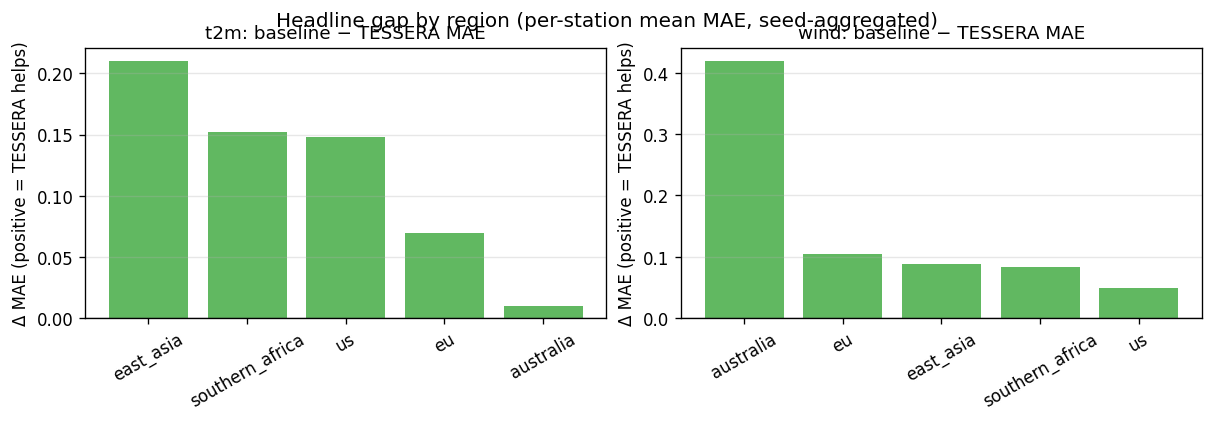

                      folder variable  baseline  tessera      gap
      snapshot_14y_east_asia      t2m  1.307389 1.097129 0.210259
snapshot_14y_southern_africa      t2m  1.945657 1.793308 0.152349
             snapshot_14y_us      t2m  1.543011 1.395045 0.147966
             snapshot_14y_eu      t2m  1.216265 1.147087 0.069179
      snapshot_14y_australia      t2m  2.009146 1.999152 0.009995
      snapshot_14y_australia     wind  1.775926 1.356504 0.419422
             snapshot_14y_eu     wind  1.372883 1.267877 0.105007
      snapshot_14y_east_asia     wind  1.243084 1.154354 0.088730
snapshot_14y_southern_africa     wind  1.294177 1.210134 0.084042
             snapshot_14y_us     wind  1.392367 1.342957 0.049410


In [8]:
# === Axis 1: region (gap as the headline) ===
# One bar per (variable, folder): height = baseline_mae − tessera_mae.
# Positive bars are where TESSERA helps; negative is where it hurts.
overall = (
    station_agg
    .groupby(['folder', 'variable', 'role'], as_index=False)['mae']
    .mean()
    .pivot_table(index=['folder', 'variable'], columns='role', values='mae')
    .reset_index()
)
overall['gap'] = overall['baseline'] - overall['tessera']

fig, axes = plt.subplots(1, len(VARIABLES), figsize=(5 * len(VARIABLES), 3.3),
                         sharey=False, squeeze=False)
for ci, variable in enumerate(VARIABLES):
    ax = axes[0, ci]
    sub = overall[overall['variable'] == variable].copy()
    sub['region'] = sub['folder'].str.replace('snapshot_14y_', '', regex=False)
    sub = sub.sort_values('gap', ascending=False)
    colours = ['#2ca02c' if g > 0 else '#d62728' for g in sub['gap']]
    ax.bar(sub['region'], sub['gap'], color=colours, alpha=0.75)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f'{variable}: baseline − TESSERA MAE')
    ax.set_ylabel('Δ MAE (positive = TESSERA helps)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Headline gap by region (per-station mean MAE, seed-aggregated)',
             fontsize=12, y=1.02)
plt.show()

with pd.option_context('display.max_rows', None, 'display.width', 200):
    print(overall.sort_values(['variable', 'gap'], ascending=[True, False]).to_string(index=False))


Bin → elevation range, per (folder, variable):
  snapshot_14y_australia / t2m:
                 min         max  count
elev_bin                               
0           3.700000   93.099998      8
1          94.000000  153.600006      6
2         176.399994  341.700012      8
3         396.000000  545.299988      6
  snapshot_14y_australia / wind:
                 min         max  count
elev_bin                               
0           3.700000   93.099998      8
1         133.800003  176.399994      6
2         178.000000  341.700012      6
3         396.000000  545.299988      6
  snapshot_14y_east_asia / t2m:
                 min          max  count
elev_bin                                
0           1.800000    17.000000     44
1          18.000000    42.200001     44
2          43.000000   114.900002     44
3         141.100006  1950.000000     44
  snapshot_14y_east_asia / wind:
                 min          max  count
elev_bin                                
0           1.8

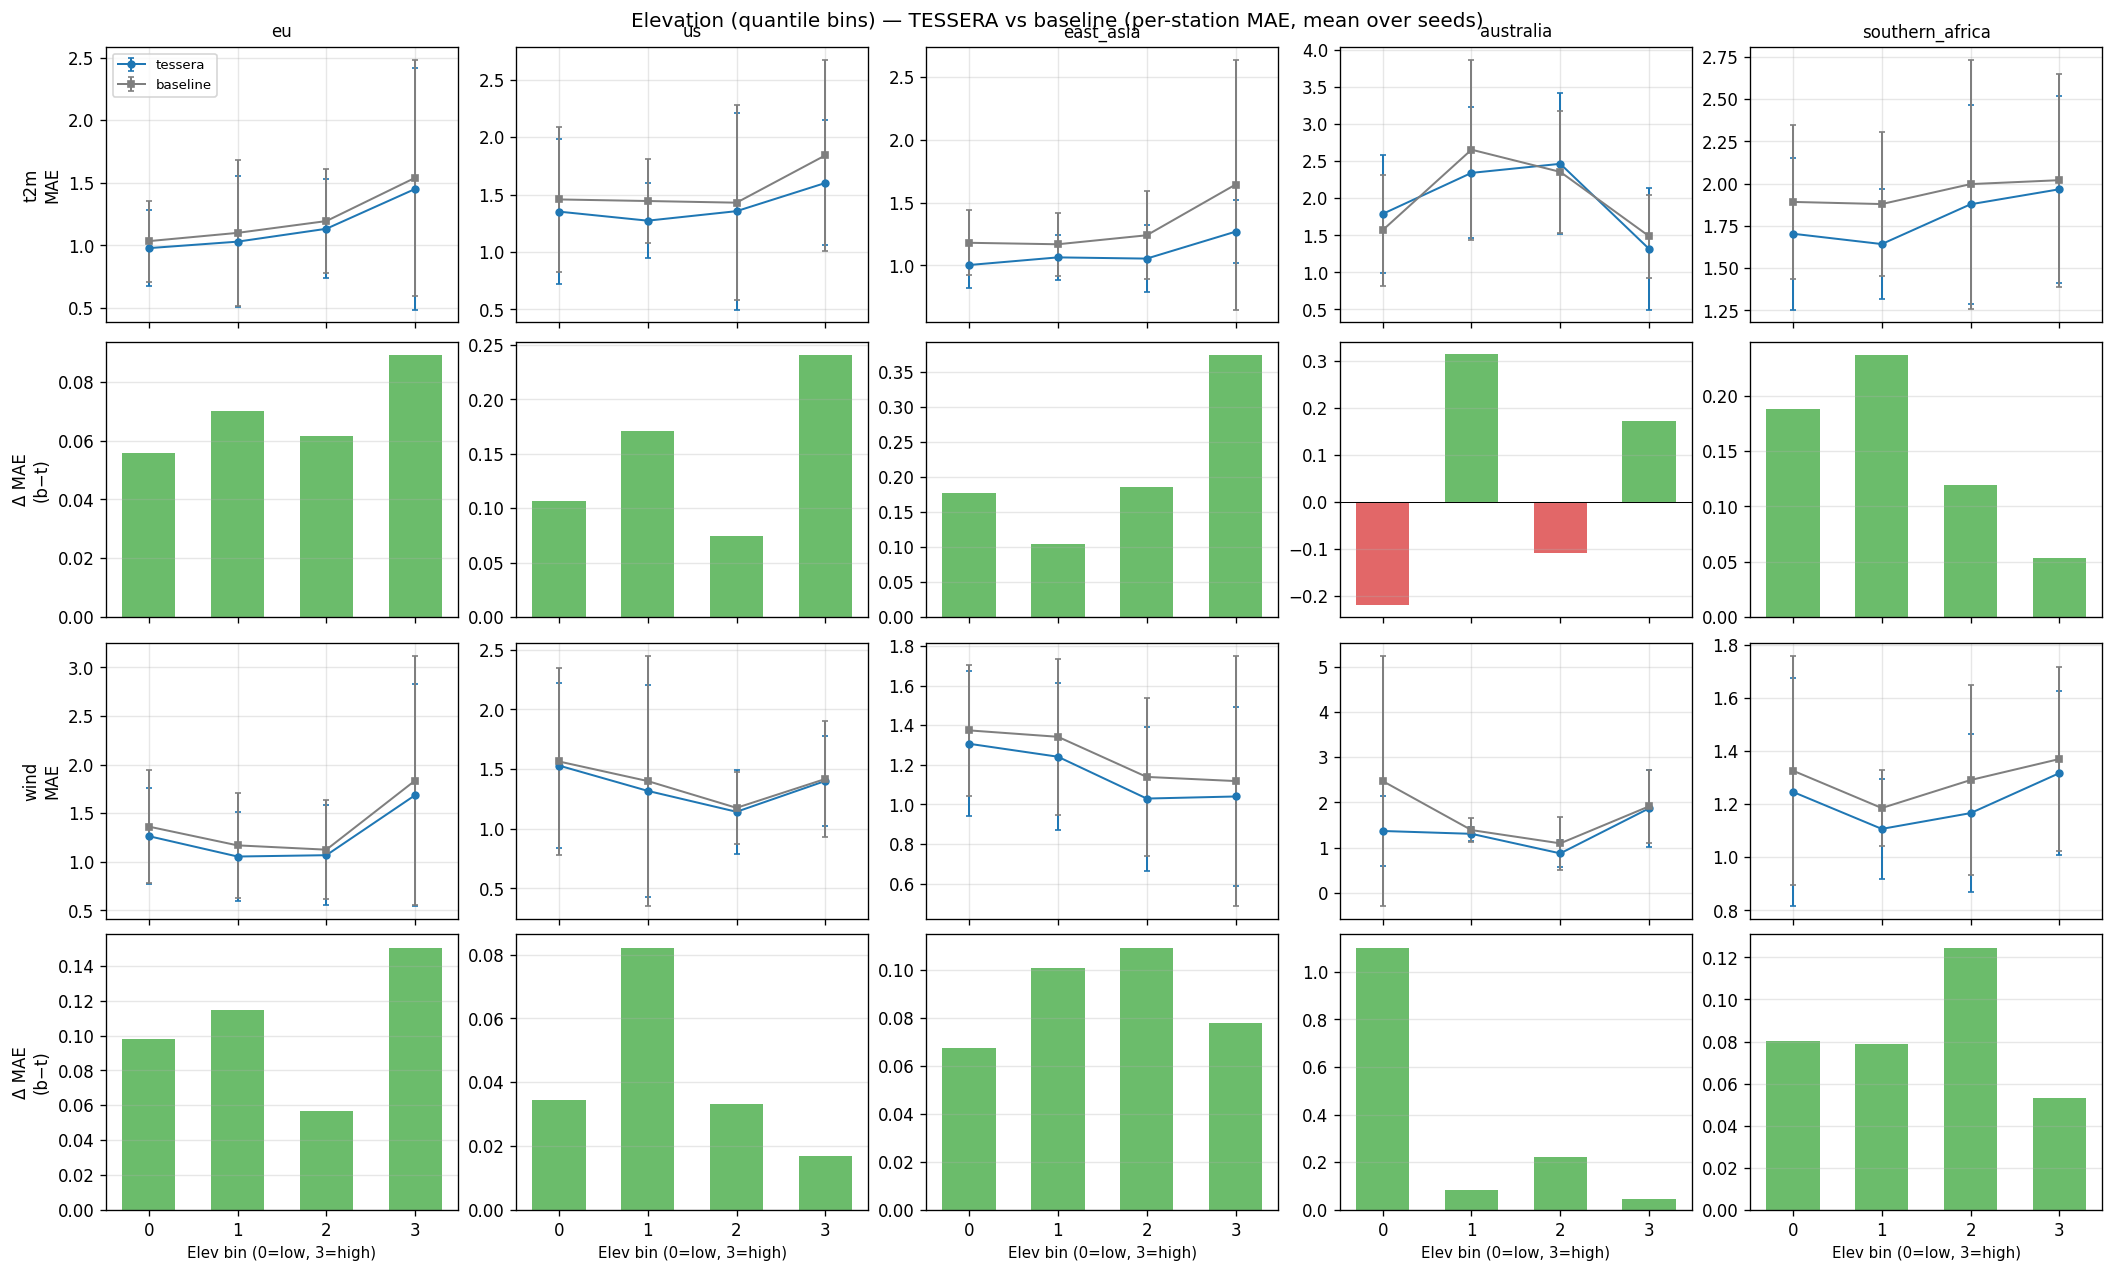

,folder,variable,role,stratum,mae_mean,mae_std,n_stations
0,snapshot_14y_australia,t2m,baseline,0,1.569433,0.747441,4
1,snapshot_14y_australia,t2m,baseline,1,2.655044,1.216101,3
2,snapshot_14y_australia,t2m,baseline,2,2.355324,0.818230,4
3,snapshot_14y_australia,t2m,baseline,3,1.487962,0.557146,3
4,snapshot_14y_australia,t2m,tessera,0,1.788663,0.800231,4
...,...,...,...,...,...,...,...
75,snapshot_14y_us,wind,baseline,3,1.416361,0.485268,81
76,snapshot_14y_us,wind,tessera,0,1.528515,0.689294,86
77,snapshot_14y_us,wind,tessera,1,1.316480,0.889967,96
78,snapshot_14y_us,wind,tessera,2,1.141233,0.352715,94


In [9]:
# === Axis 2: elevation quantile bin ===
# Bin labels are 0..N_BINS-1 (quantile index). The actual elevation
# ranges for each bin vary by region — print them per (folder, variable)
# for context.
print('Bin → elevation range, per (folder, variable):')
for (folder, variable), g in station_agg.groupby(['folder', 'variable']):
    if 'elev_bin' not in g or g['elev_bin'].isna().all():
        continue
    ranges = g.groupby('elev_bin')['elev'].agg(['min', 'max', 'count'])
    print(f'  {folder} / {variable}:')
    print(ranges.to_string())
plot_axis_grid(
    station_agg, 'elev_bin',
    axis_title='Elevation (quantile bins)',
    xlabel='Elev bin (0=low, 3=high)',
)


Bin → |Δ-elev| range, per (folder, variable):
  snapshot_14y_australia / t2m:
                          min         max  count
abs_delta_elev_bin                              
0                    3.509645   16.425859      8
1                   23.869543   31.907068      6
2                   41.886570   49.036388      8
3                   76.405785  110.405968      6
  snapshot_14y_australia / wind:
                          min         max  count
abs_delta_elev_bin                              
0                   10.755774   23.869543      8
1                   31.815056   41.886570      6
2                   47.618256   49.036388      6
3                   76.405785  110.405968      6
  snapshot_14y_east_asia / t2m:
                           min          max  count
abs_delta_elev_bin                                
0                     0.755182    18.518583     44
1                    19.279501    82.982895     44
2                    83.014435   172.757553     44
3             

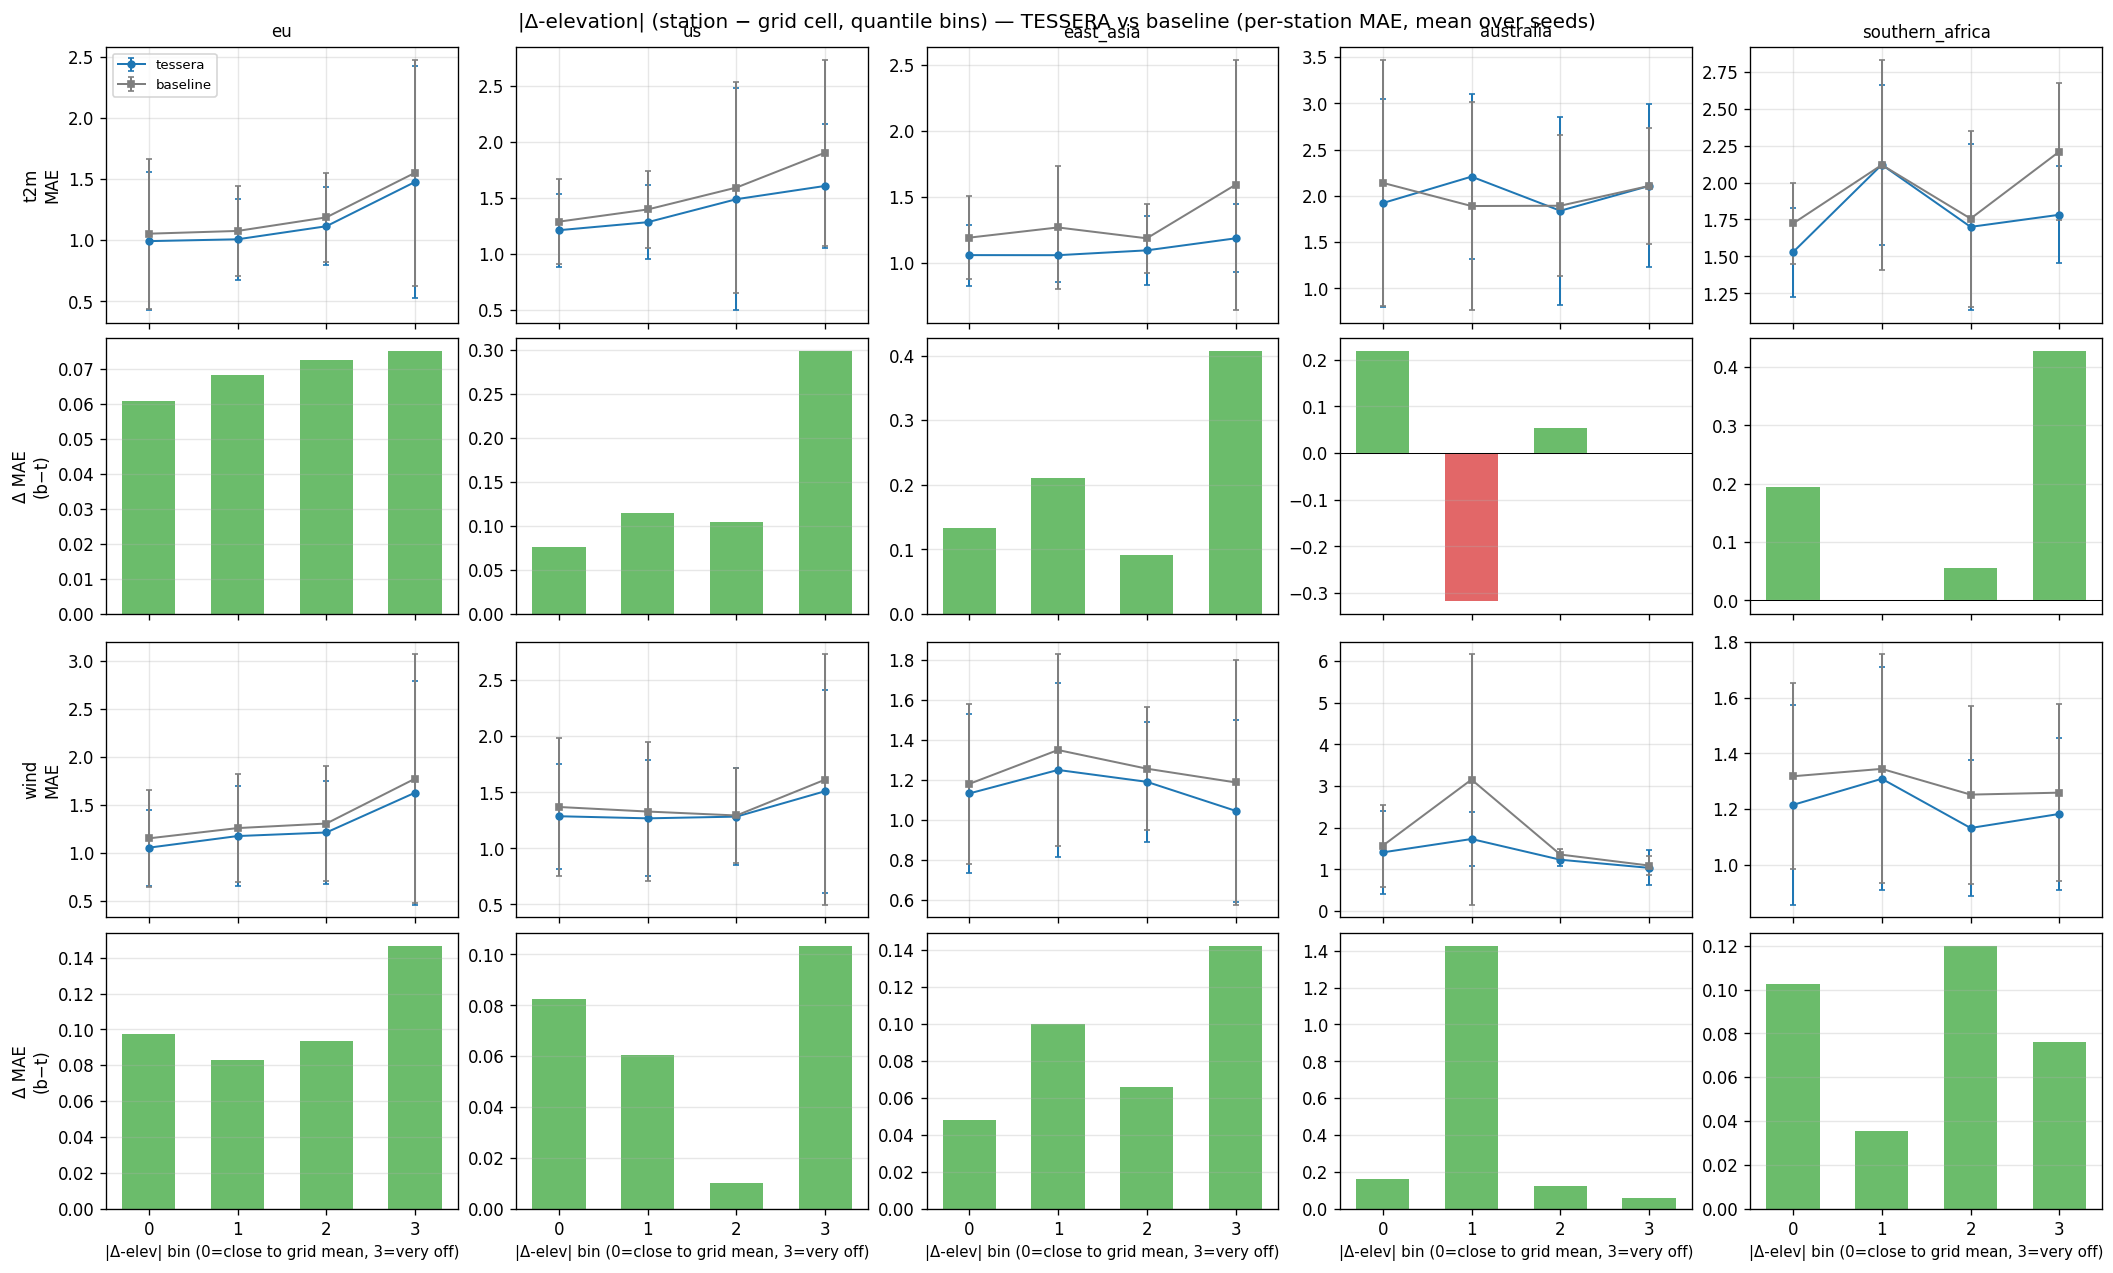

,folder,variable,role,stratum,mae_mean,mae_std,n_stations
0,snapshot_14y_australia,t2m,baseline,0,2.140794,1.332636,4
1,snapshot_14y_australia,t2m,baseline,1,1.890095,1.123318,3
2,snapshot_14y_australia,t2m,baseline,2,1.893241,0.761276,4
3,snapshot_14y_australia,t2m,baseline,3,2.107208,0.631597,3
4,snapshot_14y_australia,t2m,tessera,0,1.921736,1.127637,4
...,...,...,...,...,...,...,...
75,snapshot_14y_us,wind,baseline,3,1.613533,1.116702,76
76,snapshot_14y_us,wind,tessera,0,1.286583,0.468772,96
77,snapshot_14y_us,wind,tessera,1,1.267904,0.518295,90
78,snapshot_14y_us,wind,tessera,2,1.283272,0.432599,85


In [10]:
# === Axis 3: |Δ-elevation| quantile bin ===
# |Δ| because the sign isn't the variable of interest — what matters
# is how unrepresentative the station is of its grid cell.
print('Bin → |Δ-elev| range, per (folder, variable):')
for (folder, variable), g in station_agg.groupby(['folder', 'variable']):
    if 'abs_delta_elev_bin' not in g or g['abs_delta_elev_bin'].isna().all():
        continue
    ranges = g.groupby('abs_delta_elev_bin')['abs_delta_elev'].agg(['min', 'max', 'count'])
    print(f'  {folder} / {variable}:')
    print(ranges.to_string())
plot_axis_grid(
    station_agg, 'abs_delta_elev_bin',
    axis_title='|Δ-elevation| (station − grid cell, quantile bins)',
    xlabel='|Δ-elev| bin (0=close to grid mean, 3=very off)',
)


Bin → density range (mean dist to k=5 train stations, lat/lon degrees), per (folder, variable):
  snapshot_14y_australia / t2m:
                    min         max  count
density_bin                               
0            209.773008  215.334616      8
1            216.018543  220.561036      6
2            221.340930  226.742177      8
3            227.725003  232.196713      6
  snapshot_14y_australia / wind:
                    min         max  count
density_bin                               
0            209.773008  215.334616      8
1            216.018543  221.340930      6
2            221.529720  226.742177      6
3            227.725003  232.196713      6
  snapshot_14y_east_asia / t2m:
                  min       max  count
density_bin                           
0            0.033598  0.196531     44
1            0.201482  0.360480     44
2            0.361193  0.615065     44
3            0.629596  1.142254     44
  snapshot_14y_east_asia / wind:
                  min   

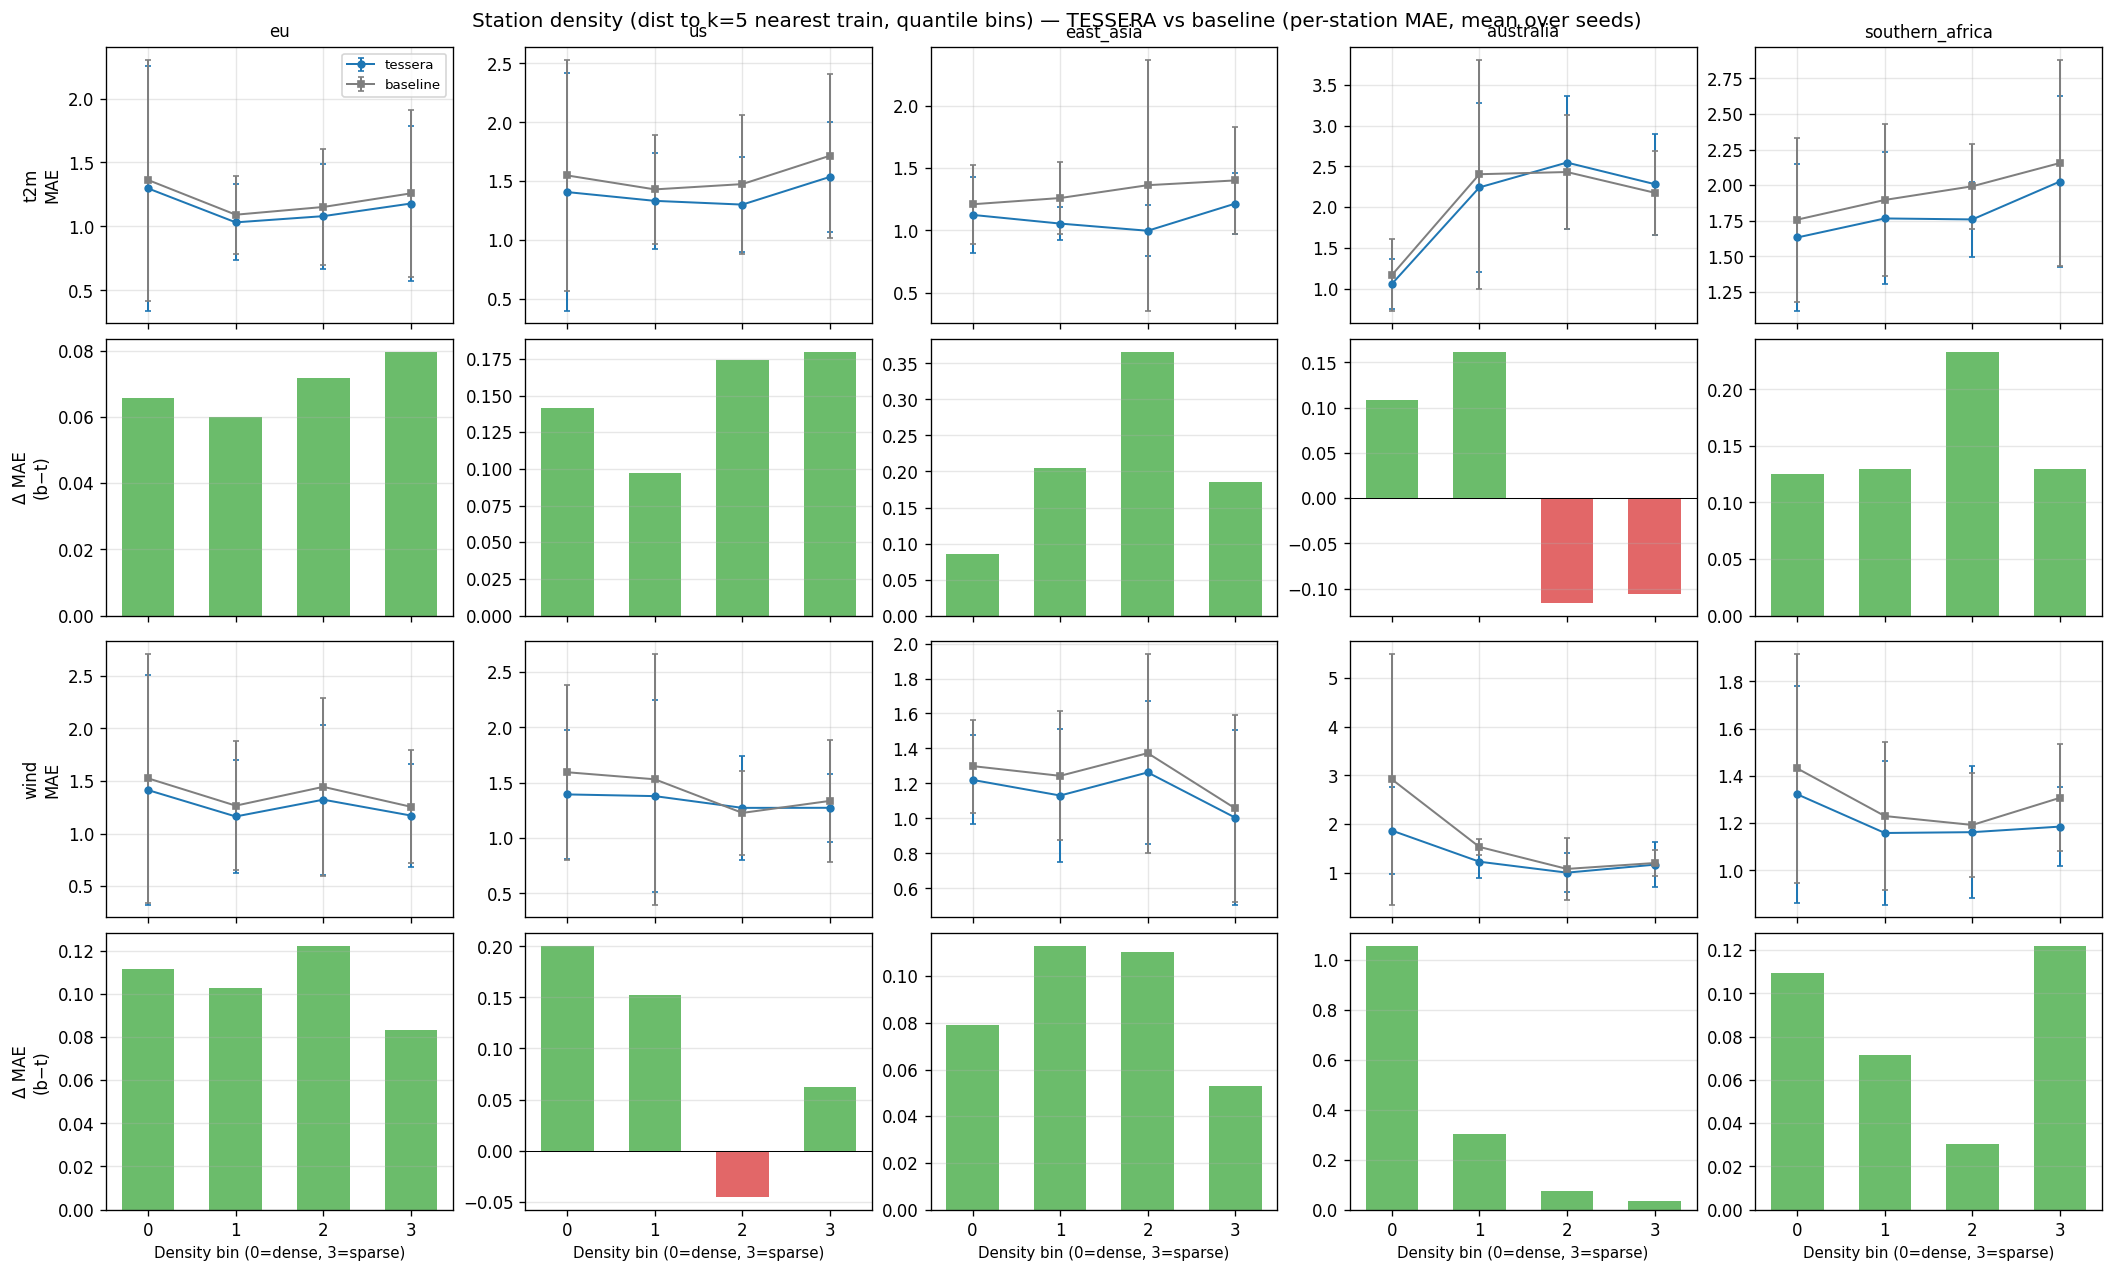

,folder,variable,role,stratum,mae_mean,mae_std,n_stations
0,snapshot_14y_australia,t2m,baseline,0,1.166781,0.436739,4
1,snapshot_14y_australia,t2m,baseline,1,2.403329,1.404414,3
2,snapshot_14y_australia,t2m,baseline,2,2.430123,0.693460,4
3,snapshot_14y_australia,t2m,baseline,3,2.176815,0.512348,3
4,snapshot_14y_australia,t2m,tessera,0,1.058047,0.304985,4
...,...,...,...,...,...,...,...
75,snapshot_14y_us,wind,baseline,3,1.336112,0.550544,121
76,snapshot_14y_us,wind,tessera,0,1.394590,0.586731,118
77,snapshot_14y_us,wind,tessera,1,1.379233,0.865311,111
78,snapshot_14y_us,wind,tessera,2,1.272906,0.468820,87


In [11]:
# === Axis 4: station density (k-NN distance to train stations) ===
# Bigger bin = sparser region (longer mean distance to nearest k=5 train
# stations). The TESSERA-helps-sparse-areas hypothesis predicts the gap
# grows monotonically left → right.
print('Bin → density range (mean dist to k=5 train stations, lat/lon degrees), per (folder, variable):')
for (folder, variable), g in station_agg.groupby(['folder', 'variable']):
    if 'density_bin' not in g or g['density_bin'].isna().all():
        continue
    ranges = g.groupby('density_bin')['density'].agg(['min', 'max', 'count'])
    print(f'  {folder} / {variable}:')
    print(ranges.to_string())
plot_axis_grid(
    station_agg, 'density_bin',
    axis_title='Station density (dist to k=5 nearest train, quantile bins)',
    xlabel='Density bin (0=dense, 3=sparse)',
)


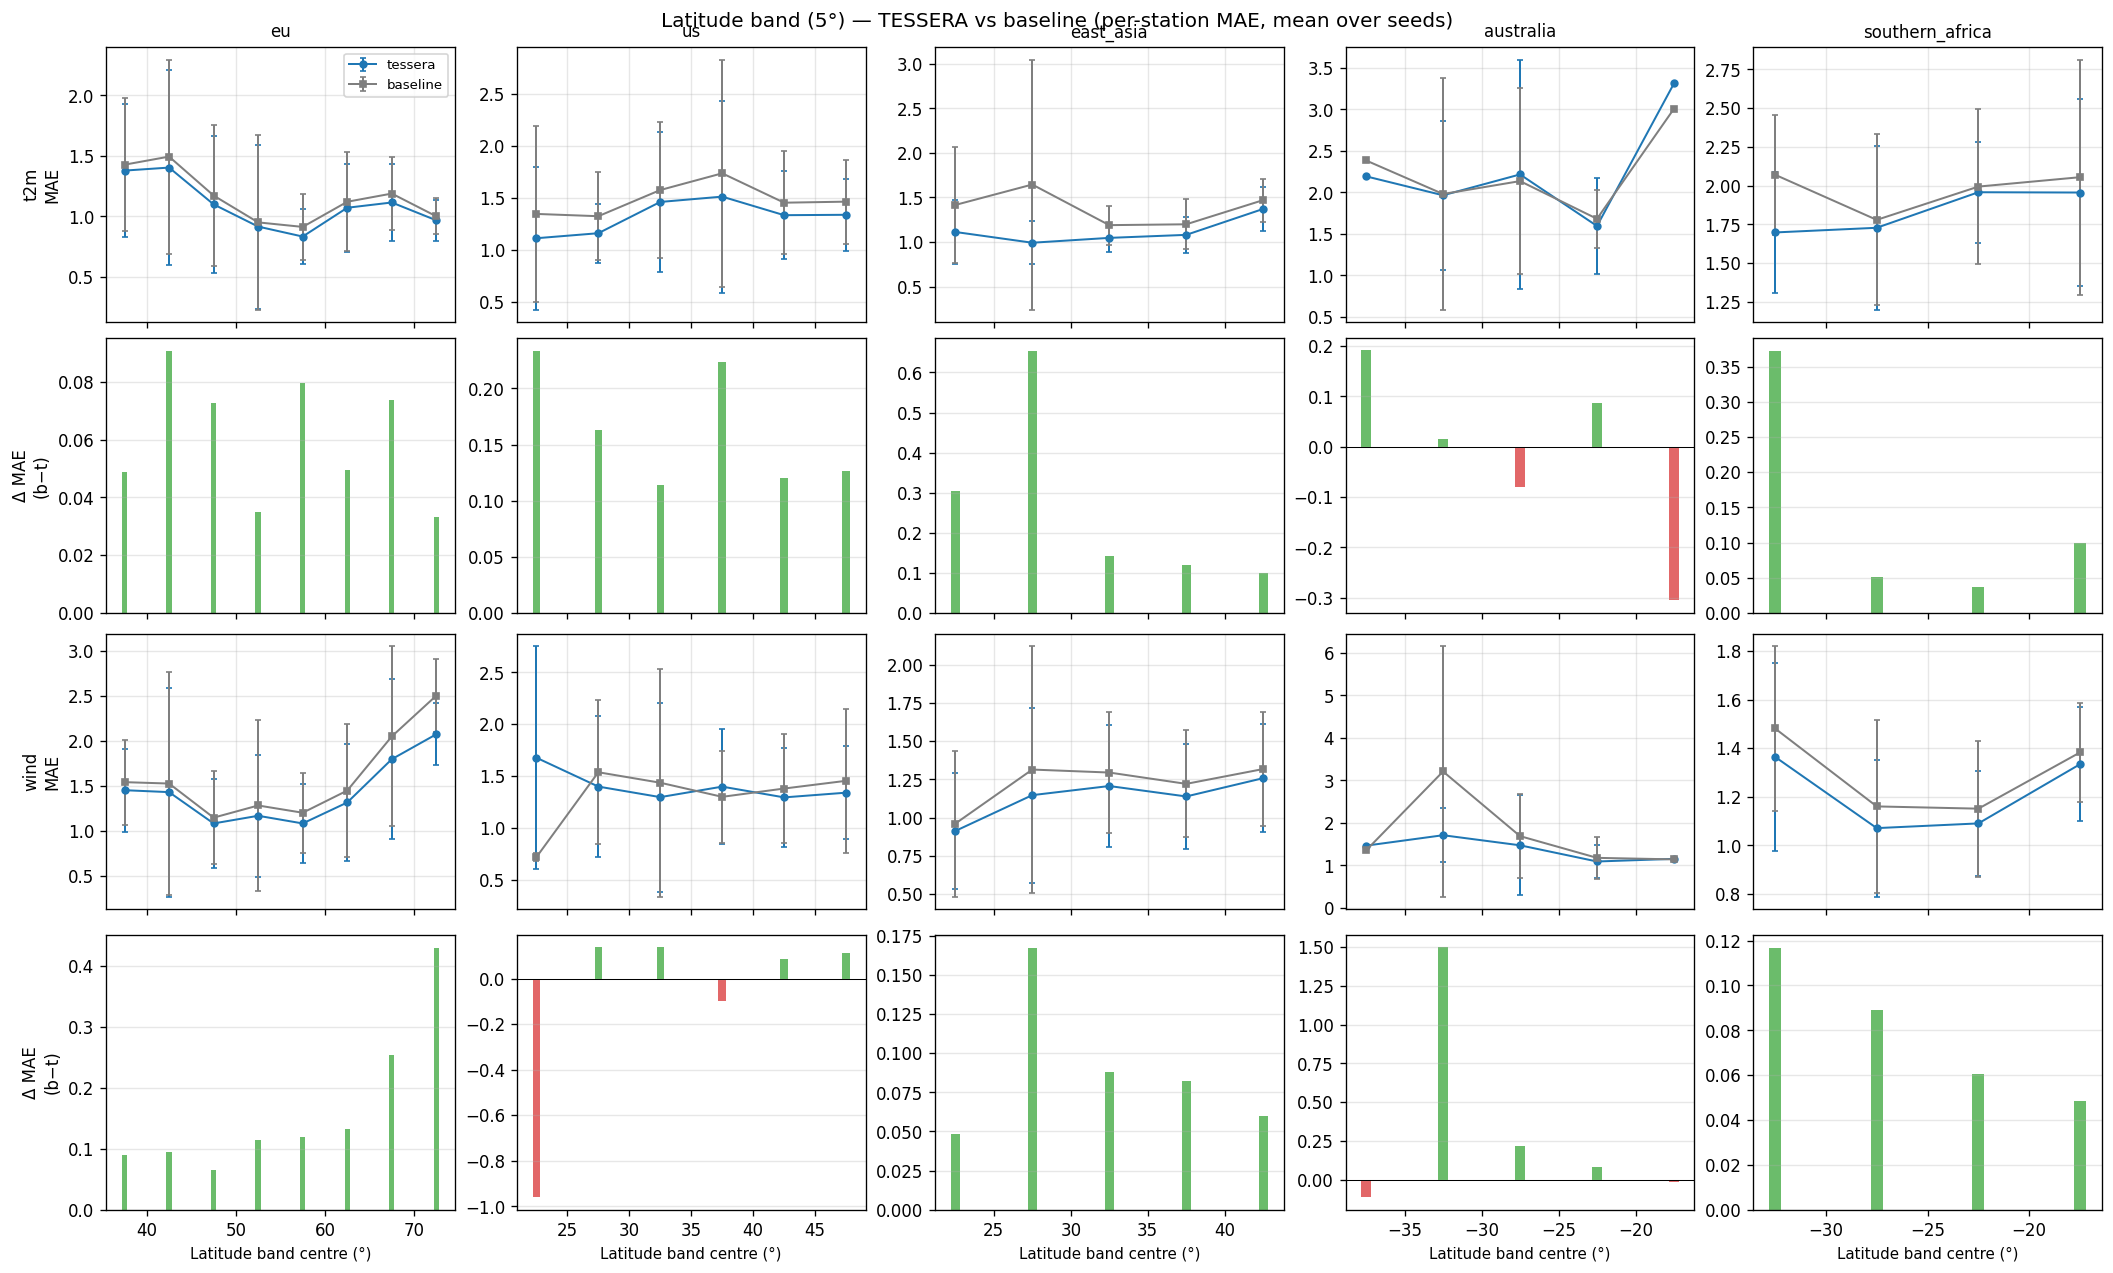

,folder,variable,role,stratum,mae_mean,mae_std,n_stations
0,snapshot_14y_australia,t2m,baseline,-37.5,2.384903,0.000000,1
1,snapshot_14y_australia,t2m,baseline,-32.5,1.980310,1.393885,4
2,snapshot_14y_australia,t2m,baseline,-27.5,2.135890,1.125211,3
3,snapshot_14y_australia,t2m,baseline,-22.5,1.681017,0.350113,5
4,snapshot_14y_australia,t2m,baseline,-17.5,3.009151,0.000000,1
...,...,...,...,...,...,...,...
107,snapshot_14y_us,wind,tessera,27.5,1.397783,0.676496,36
108,snapshot_14y_us,wind,tessera,32.5,1.295986,0.912649,78
109,snapshot_14y_us,wind,tessera,37.5,1.397240,0.553040,97
110,snapshot_14y_us,wind,tessera,42.5,1.293488,0.474773,94


In [12]:
# === Axis 5: latitude band (fixed 5° bins) ===
# Unlike the quantile axes, lat_band is cross-folder commensurable (5°
# bins are absolute), so per-region differences in shape are physically
# interpretable as latitude effects.
# Convert lat_band Interval → mid-point for plotting.
station_agg['lat_band_mid'] = station_agg['lat_band'].apply(
    lambda iv: float(iv.mid) if pd.notna(iv) else np.nan
)
plot_axis_grid(
    station_agg, 'lat_band_mid',
    axis_title='Latitude band (5°)',
    xlabel='Latitude band centre (°)',
)


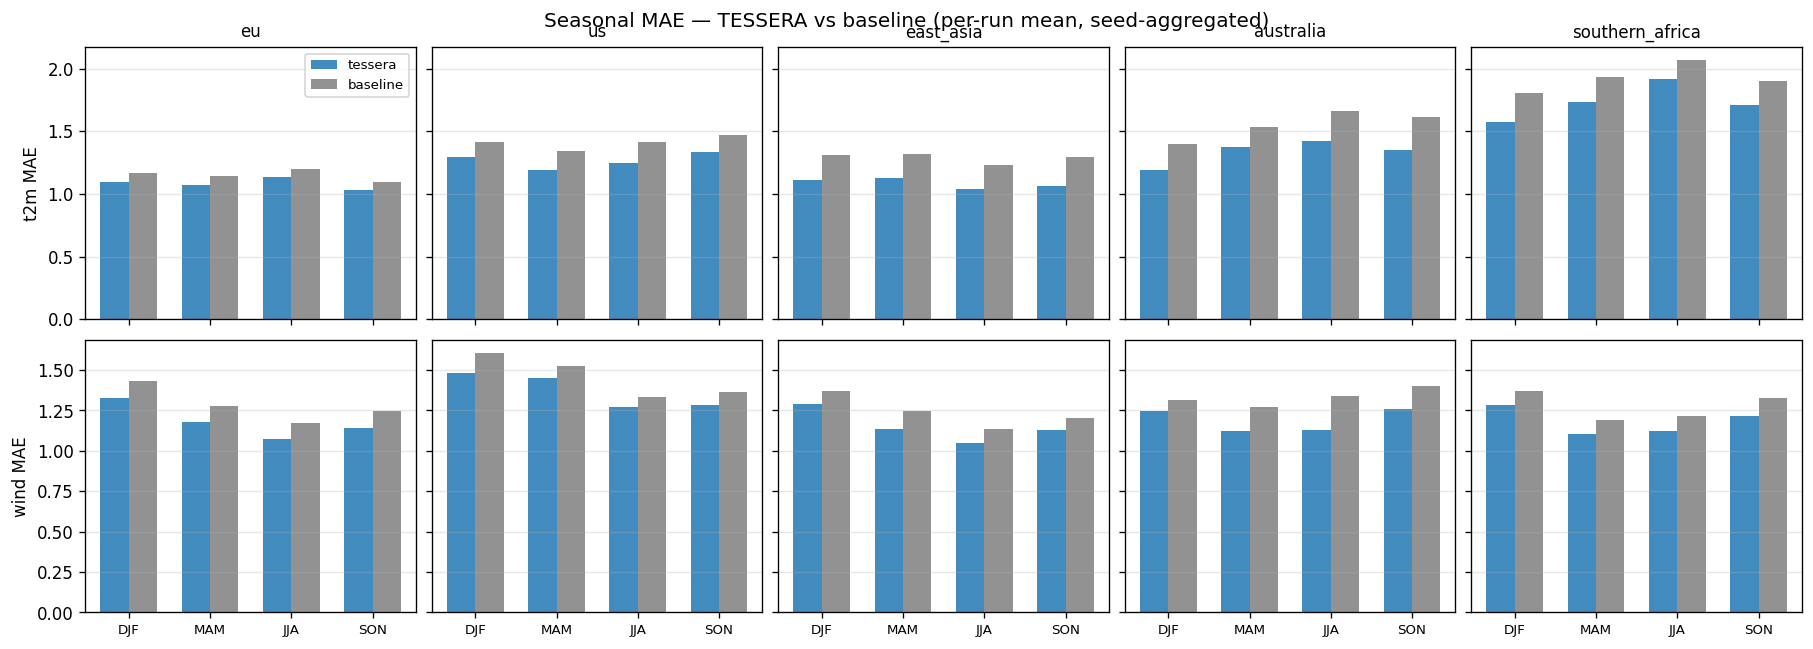

In [13]:
# === Axis 6: season (from test_summary.json's {var}_seasonal_mae) ===
# Per-station seasonal MAE is NOT recorded by evaluate.py; only an
# aggregate per (run, season) is. So this axis is plotted at the
# (folder, role, season) level. Smaller error bars than the per-station
# axes — fewer aggregation degrees of freedom.
SEASONS = ['DJF', 'MAM', 'JJA', 'SON']
season_rows = []
for w in winners:
    for role, exp in [('tessera', w['tessera_experiment']),
                      ('baseline', w['baseline_experiment'])]:
        rows = df_all[
            (df_all['source_folder'] == w['folder'])
            & (df_all['experiment'] == exp)
        ]
        for season in SEASONS:
            col = f'{w["variable"]}_mae_{season}'
            if col not in rows.columns:
                continue
            vals = rows[col].dropna()
            if vals.empty:
                continue
            season_rows.append({
                'folder':     w['folder'],
                'variable':   w['variable'],
                'role':       role,
                'season':     season,
                'mae_mean':   vals.mean(),
                'mae_std':    vals.std() if len(vals) > 1 else 0.0,
                'n_seeds':    len(vals),
            })
season_df = pd.DataFrame(season_rows)

fig, axes = plt.subplots(
    len(VARIABLES), len(winners_df['folder'].unique()),
    figsize=(3 * len(winners_df['folder'].unique()), 2.6 * len(VARIABLES)),
    sharex=True, sharey='row', squeeze=False,
)
fig.suptitle('Seasonal MAE — TESSERA vs baseline (per-run mean, seed-aggregated)',
             fontsize=12, y=1.01)
for ci, folder in enumerate(winners_df['folder'].unique()):
    for vi, variable in enumerate(VARIABLES):
        ax = axes[vi, ci]
        sub = season_df[
            (season_df['folder'] == folder)
            & (season_df['variable'] == variable)
        ]
        if sub.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='#999999')
            continue
        sub = sub.set_index(['season', 'role'])['mae_mean'].unstack('role')
        sub = sub.reindex(SEASONS)
        x = np.arange(len(SEASONS))
        w_bar = 0.35
        for offset, role in [(-w_bar/2, 'tessera'), (+w_bar/2, 'baseline')]:
            if role in sub.columns:
                ax.bar(x + offset, sub[role].values, width=w_bar,
                       color=ROLE_COLOUR[role], alpha=0.85, label=role)
        ax.set_xticks(x); ax.set_xticklabels(SEASONS, fontsize=8)
        if ci == 0:
            ax.set_ylabel(f'{variable} MAE')
        if vi == 0:
            ax.set_title(folder.replace('snapshot_14y_', ''), fontsize=10)
        if vi == 0 and ci == 0:
            ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3, axis='y')
plt.show()


In [14]:
# === Summary: gap per (folder, variable, axis) ===
# One row per (folder, variable, axis) with overall TESSERA / baseline MAE,
# the overall gap, and a monotonicity indicator: does the gap shrink (-) or
# grow (+) as the stratum index increases? Sign tells you which end of the
# axis benefits most from TESSERA.
def axis_summary(sdf, col, label):
    agg = aggregate_by_stratum(sdf, col)
    out = []
    for (folder, variable), g in agg.groupby(['folder', 'variable']):
        t = g[g['role'] == 'tessera'].set_index('stratum')['mae_mean']
        b = g[g['role'] == 'baseline'].set_index('stratum')['mae_mean']
        common = sorted(set(t.index) & set(b.index))
        if len(common) < 2:
            continue
        gap = pd.Series([b.loc[s] - t.loc[s] for s in common], index=common)
        out.append({
            'folder':     folder,
            'variable':   variable,
            'axis':       label,
            'mean_gap':   gap.mean(),
            'gap_first':  gap.iloc[0],
            'gap_last':   gap.iloc[-1],
            'gap_trend':  gap.iloc[-1] - gap.iloc[0],
        })
    return pd.DataFrame(out)


summary = pd.concat([
    axis_summary(station_agg, 'elev_bin',            'elevation'),
    axis_summary(station_agg, 'abs_delta_elev_bin',  '|Δ-elev|'),
    axis_summary(station_agg, 'density_bin',         'density'),
    axis_summary(station_agg, 'lat_band_mid',        'latitude'),
], ignore_index=True)

with pd.option_context('display.max_rows', None, 'display.width', 200,
                        'display.float_format', '{:.4f}'.format):
    print(summary.sort_values(['variable', 'folder', 'axis']).to_string(index=False))


                      folder variable      axis  mean_gap  gap_first  gap_last  gap_trend
      snapshot_14y_australia      t2m   density    0.0123     0.1087   -0.1055    -0.2143
      snapshot_14y_australia      t2m elevation    0.0390    -0.2192    0.1712     0.3904
      snapshot_14y_australia      t2m  latitude   -0.0184     0.1915   -0.3052    -0.4967
      snapshot_14y_australia      t2m  |Δ-elev|   -0.0111     0.2191    0.0001    -0.2189
      snapshot_14y_east_asia      t2m   density    0.2103     0.0851    0.1857     0.1005
      snapshot_14y_east_asia      t2m elevation    0.2103     0.1767    0.3744     0.1978
      snapshot_14y_east_asia      t2m  latitude    0.2635     0.3034    0.0989    -0.2044
      snapshot_14y_east_asia      t2m  |Δ-elev|    0.2103     0.1325    0.4066     0.2741
             snapshot_14y_eu      t2m   density    0.0692     0.0657    0.0794     0.0138
             snapshot_14y_eu      t2m elevation    0.0692     0.0559    0.0892     0.0332
          

## Reading the plots

For each axis, the **top row of each pair** shows raw MAE for TESSERA (blue
circles) and baseline (grey squares), error bars = std across seeds. The
**bottom row of each pair** shows the per-bin gap (baseline − TESSERA):

* **Green bars** = TESSERA helps in that stratum.
* **Red bars**   = baseline beats TESSERA there.

### What to look for

1. **Region (axis 1):** which folders show the biggest gap? A folder with a
   green bar is a region where TESSERA is doing what it's supposed to do.
   Red bars (if any) flag a regime where TESSERA's spatial-context shortcut
   isn't helping — worth investigating before claiming generality.

2. **Elevation (axis 2):** does the gap grow with elevation? The Alps probe
   experiment hinted at "yes" for elevated stations; this axis tests it at
   continental scale.

3. **|Δ-elev| (axis 3):** the most direct downscaling test. Stations with
   large |Δ-elev| are precisely the ones where ERA5's grid-cell mean is
   farthest from the station's true elevation, so a smart downscaler with
   local context should help most here. If the gap is flat in |Δ-elev|, the
   model isn't actually solving the elevation-disagreement problem.

4. **Density (axis 4):** does TESSERA help more in sparse station networks?
   This is the core P1 claim. A monotonically rising gap (left → right)
   would support it.

5. **Latitude:** climate-regime proxy. Compare gap vs latitude across all
   regions — bands shared between regions (e.g. mid-latitudes 30–50°) give
   region-agnostic regime comparison.

6. **Season:** are wind / t2m harder in winter than summer? Does TESSERA
   close that gap?

### Final summary table

The last table lists `mean_gap` and `gap_trend` (last − first stratum) per
(folder, variable, axis). Positive `gap_trend` = TESSERA's relative
advantage *grows* with the stratum index; negative = shrinks. Sign tells
you which end of the axis benefits most.
